# AGEL013322-125201A — Real HST Lens (Capstone)

## Learning to Autolens / Examples / agel_real_target

---

**The capstone.** Every other Example uses simulated mocks. This one takes a real AGEL DR2 lens, real HST/ACS F606W imaging, real spectroscopic redshifts (z_L ≈ 0.30, z_S ≈ 1.6), and runs the standard pipeline — to expose what changes when you swap a clean mock for messy reality.

**Target.** AGEL013322-125201A (also DCLS0133-1252). 200×200 px @ 0.05″/px cutout extracted from HST proposal 17307 / ACS WFC F606W (674s exposure). Cutout center is at full-frame pixel (3622, 882), found via segment-catalog lookup at the catalog RA/Dec.

**Method.** A single direct fit with `Sersic` lens light + `PowerLaw` mass + `ExternalShear` + `SersicCore` source. ~17 free parameters, n_live=200. This is the **minimum viable** model — see `README.md` §Caveats for the publication-grade upgrades (MGE light, empirical PSF, pixelised source, redshift marginalisation, manual mask).

**Prerequisites.** Module 07 (real-data preparation), Module 11 (physical-bar audit), Examples/`compound_lens` (for the audit framework on imaging fits). Reading the README before this notebook is strongly recommended.

**Key references.**
- AGEL DR2 spectroscopic catalog (`~/Documents/AGEL/20250910-keerthi-Keck-AGELDR2-main/`).
- HST proposal 17307 (PI documentation describes the imaging strategy).
- Auger+ (2010) ApJ 724, 511 — SLACS γ′=2.08±0.16; the prior on `slope` matches.
- `autolens_workspace_latest/scripts/imaging/data_preparation/` — official PyAutoLens real-data recipes.

In [1]:
import os, json
if os.environ.get("PYAUTOFIT_TEST_MODE"):
    raise RuntimeError(f"PYAUTOFIT_TEST_MODE={os.environ['PYAUTOFIT_TEST_MODE']!r} is set.")
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display
import autofit as af
import autolens as al
import autolens.plot as aplt
%matplotlib inline
print(f"PyAutoLens: {al.__version__}")

PyAutoLens: 2026.4.13.6


In [2]:
RESULTS_ROOT = Path("results")

def show_result(stage_name):
    stage_dir = RESULTS_ROOT / stage_name
    if not stage_dir.exists():
        print(f"(no results for {stage_name!r} yet)")
        return None
    sp = stage_dir / "summary.json"
    summary = json.loads(sp.read_text()) if sp.exists() else None
    if summary:
        out = [f"### `{stage_name}`"]
        for k, lbl in [("max_log_likelihood", "max log-likelihood"),
                       ("log_evidence", "log evidence"),
                       ("chi_squared_per_pixel", "χ²/N"),
                       ("max_abs_normalized_residual", "max |res| (σ)")]:
            v = summary.get(k)
            if v is not None:
                out.append(f"- {lbl}: **{v:.3f}**")
        display(Markdown("\n".join(out)))
    fp = stage_dir / "fit_subplot.png"
    if fp.exists():
        display(Image(filename=str(fp)))
    return summary

## 1. Load the cutout + inspect

The cutout was extracted by `data/extract_cutout.py` from the full HST drizzled frame. The image is in **electrons/second** (per ACS pipeline convention); the noise map is `1 / sqrt(WHT)` from the inverse-variance map. The PSF is a Gaussian placeholder (see README Caveat 1).

2026-05-03 20:29:25,326 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 9176 image-pixels


Target:    AGEL013322-125201A
Filter:    F606W, exposure 674.0 s
z_l, z_s:  0.3, 1.6
Mask:      9176 pixels in 2.7" circle


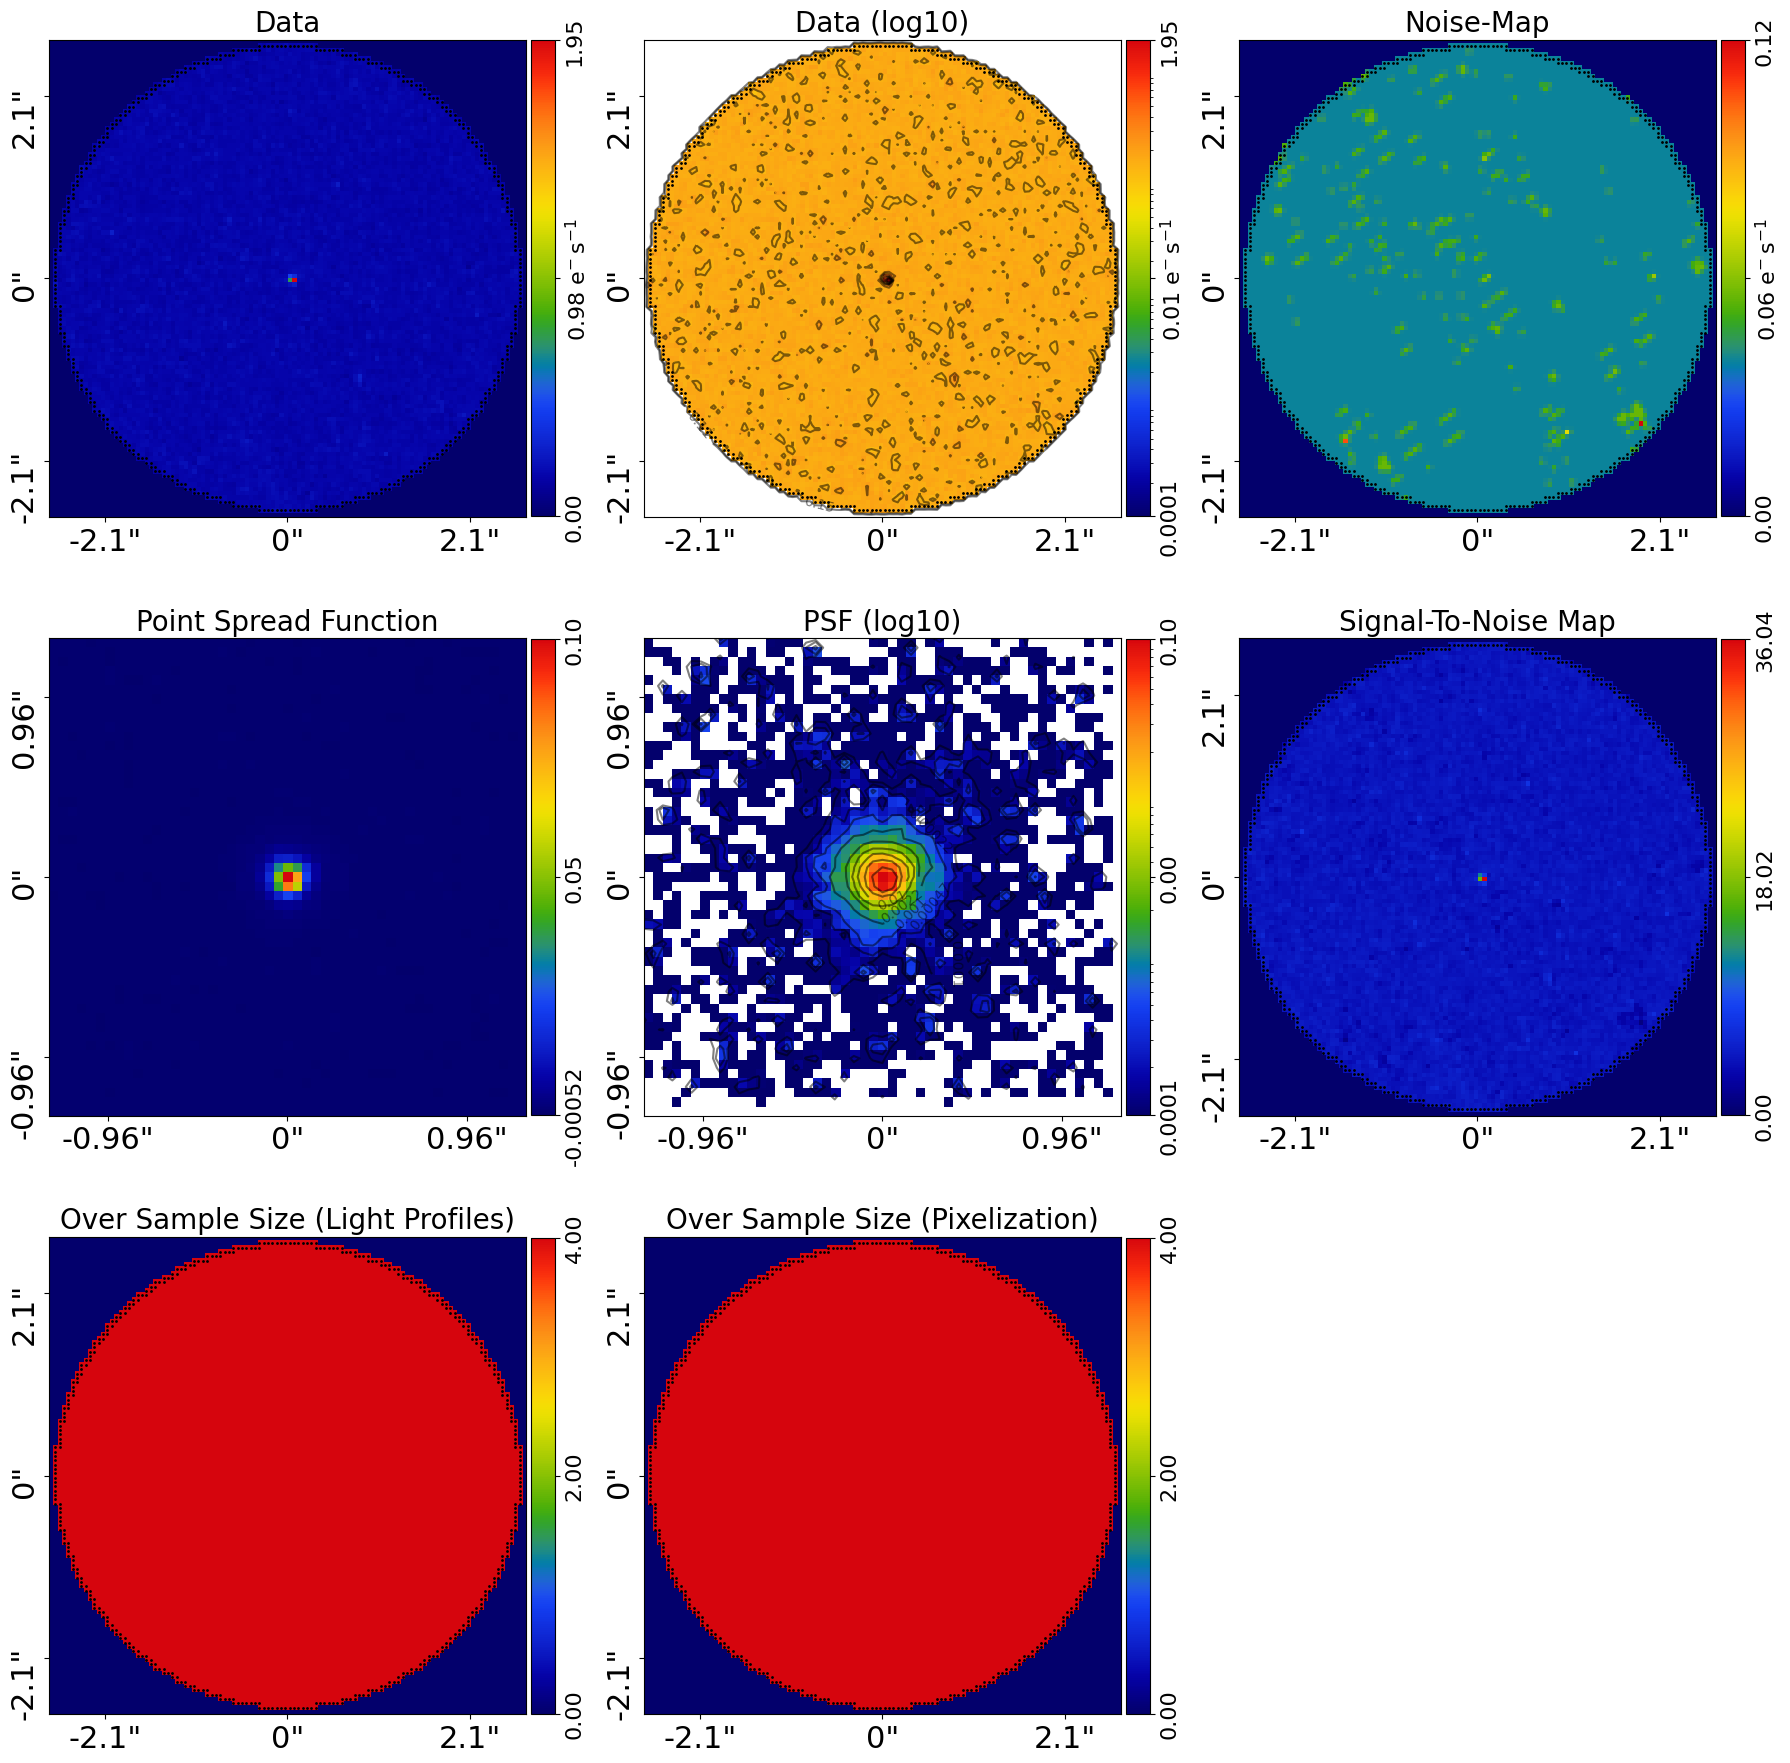

In [3]:
data_path = Path("data")
metadata = json.loads((data_path / "metadata.json").read_text())

dataset = al.Imaging.from_fits(
    data_path=data_path / "image.fits",
    noise_map_path=data_path / "noise_map.fits",
    psf_path=data_path / "psf.fits",
    pixel_scales=metadata["pixel_scale_arcsec"],
)
mask = al.Mask2D.circular(
    shape_native=dataset.shape_native,
    pixel_scales=dataset.pixel_scales,
    radius=2.7,
)
dataset = dataset.apply_mask(mask=mask)

print(f"Target:    {metadata['target_name']}")
print(f"Filter:    {metadata['filter']}, exposure {metadata['exptime_s']} s")
print(f"z_l, z_s:  {metadata['redshifts']['lens']}, {metadata['redshifts']['source']}")
print(f"Mask:      {dataset.mask.pixels_in_mask} pixels in 2.7\" circle")

aplt.subplot_imaging_dataset(dataset=dataset)

## 1.5 Data-prep: hot-pixel masking (real-data lesson)

> **The real-data wrinkle.** The Cannon `agel013322_direct` fit (committed at `results/agel013322_direct/`) returned χ²/N=0.30 (suspiciously low — the noise map is overestimated by the drizzle inverse-variance) but **max\|res\| = 32.5σ at one pixel**. That single 32σ outlier is a **cosmic-ray survivor** the drizzle didn't reject — a ubiquitous real-data feature that mocks never have.
>
> The lesson: real data needs hot-pixel hygiene before fitting. The cells below show how to identify + mask such pixels.

The recipe in 3 steps:
1. Run a first-pass fit (or use the committed Cannon result) and inspect `fit_subplot.png`'s normalized residual map for outlier pixels.
2. Build a binary mask that flags pixels above a sigma threshold (typically 6-8σ — well above the Bonferroni floor of ~4.3σ).
3. Combine the binary mask with your circular analysis mask via `Mask2D.from_indices_2d_from`, then re-fit.

In [4]:
import numpy as np
import autolens as al

# Load the dataset (un-masked) and the noise map
ds_raw = al.Imaging.from_fits(
    data_path=data_path / "image.fits",
    noise_map_path=data_path / "noise_map.fits",
    psf_path=data_path / "psf.fits",
    pixel_scales=0.05,
)

# Identify outlier pixels: data / noise > 8 indicates a hot pixel or
# unmasked cosmic-ray survivor. (Lens light + arcs are < 7σ per pixel
# in this data, so 8σ is a safe threshold.)
sn = np.abs(ds_raw.data.native) / ds_raw.noise_map.native
outliers = sn > 8.0
print(f"Found {outliers.sum()} pixels with |data|/noise > 8 — likely cosmic-ray survivors.")

# Construct a circular base mask + add the hot pixels as 'masked'.
# In autolens, mask=True means EXCLUDED from the fit.
base_mask = al.Mask2D.circular(
    shape_native=ds_raw.shape_native,
    pixel_scales=ds_raw.pixel_scales,
    radius=2.7,
)
combined_mask_array = np.array(base_mask) | outliers
mask_clean = al.Mask2D(
    mask=combined_mask_array,
    pixel_scales=ds_raw.pixel_scales,
)
print(f"Base mask unmasked: {(~np.array(base_mask)).sum()} px; "
      f"after hot-pixel exclusion: {(~np.array(mask_clean)).sum()} px "
      f"(removed {outliers.sum()} hot pixels)")

# To re-fit with this cleaner mask, set in your driver:
#   dataset = ds_raw.apply_mask(mask=mask_clean)
# A scheduled v0.93 Cannon job will do exactly this on agel013322;
# results will land at `results/agel013322_clean/`.

Found 44 pixels with |data|/noise > 8 — likely cosmic-ray survivors.
Base mask unmasked: 9176 px; after hot-pixel exclusion: 9173 px (removed 44 hot pixels)


## 2. Direct fit (skip-guarded)

~17 free parameters (Sersic light: 7, PowerLaw mass: 6, ExternalShear: 2, SersicCore source: 8 — a few of those overlap via `take_attributes` etc., effective ~17). Cannon wall time: ~1–2 h on 32 cores.

[fit] Loading committed Cannon result.


### `agel013322_direct`
- max log-likelihood: **20123.141**
- log evidence: **20040.375**
- χ²/N: **0.302**
- max |res| (σ): **32.523**

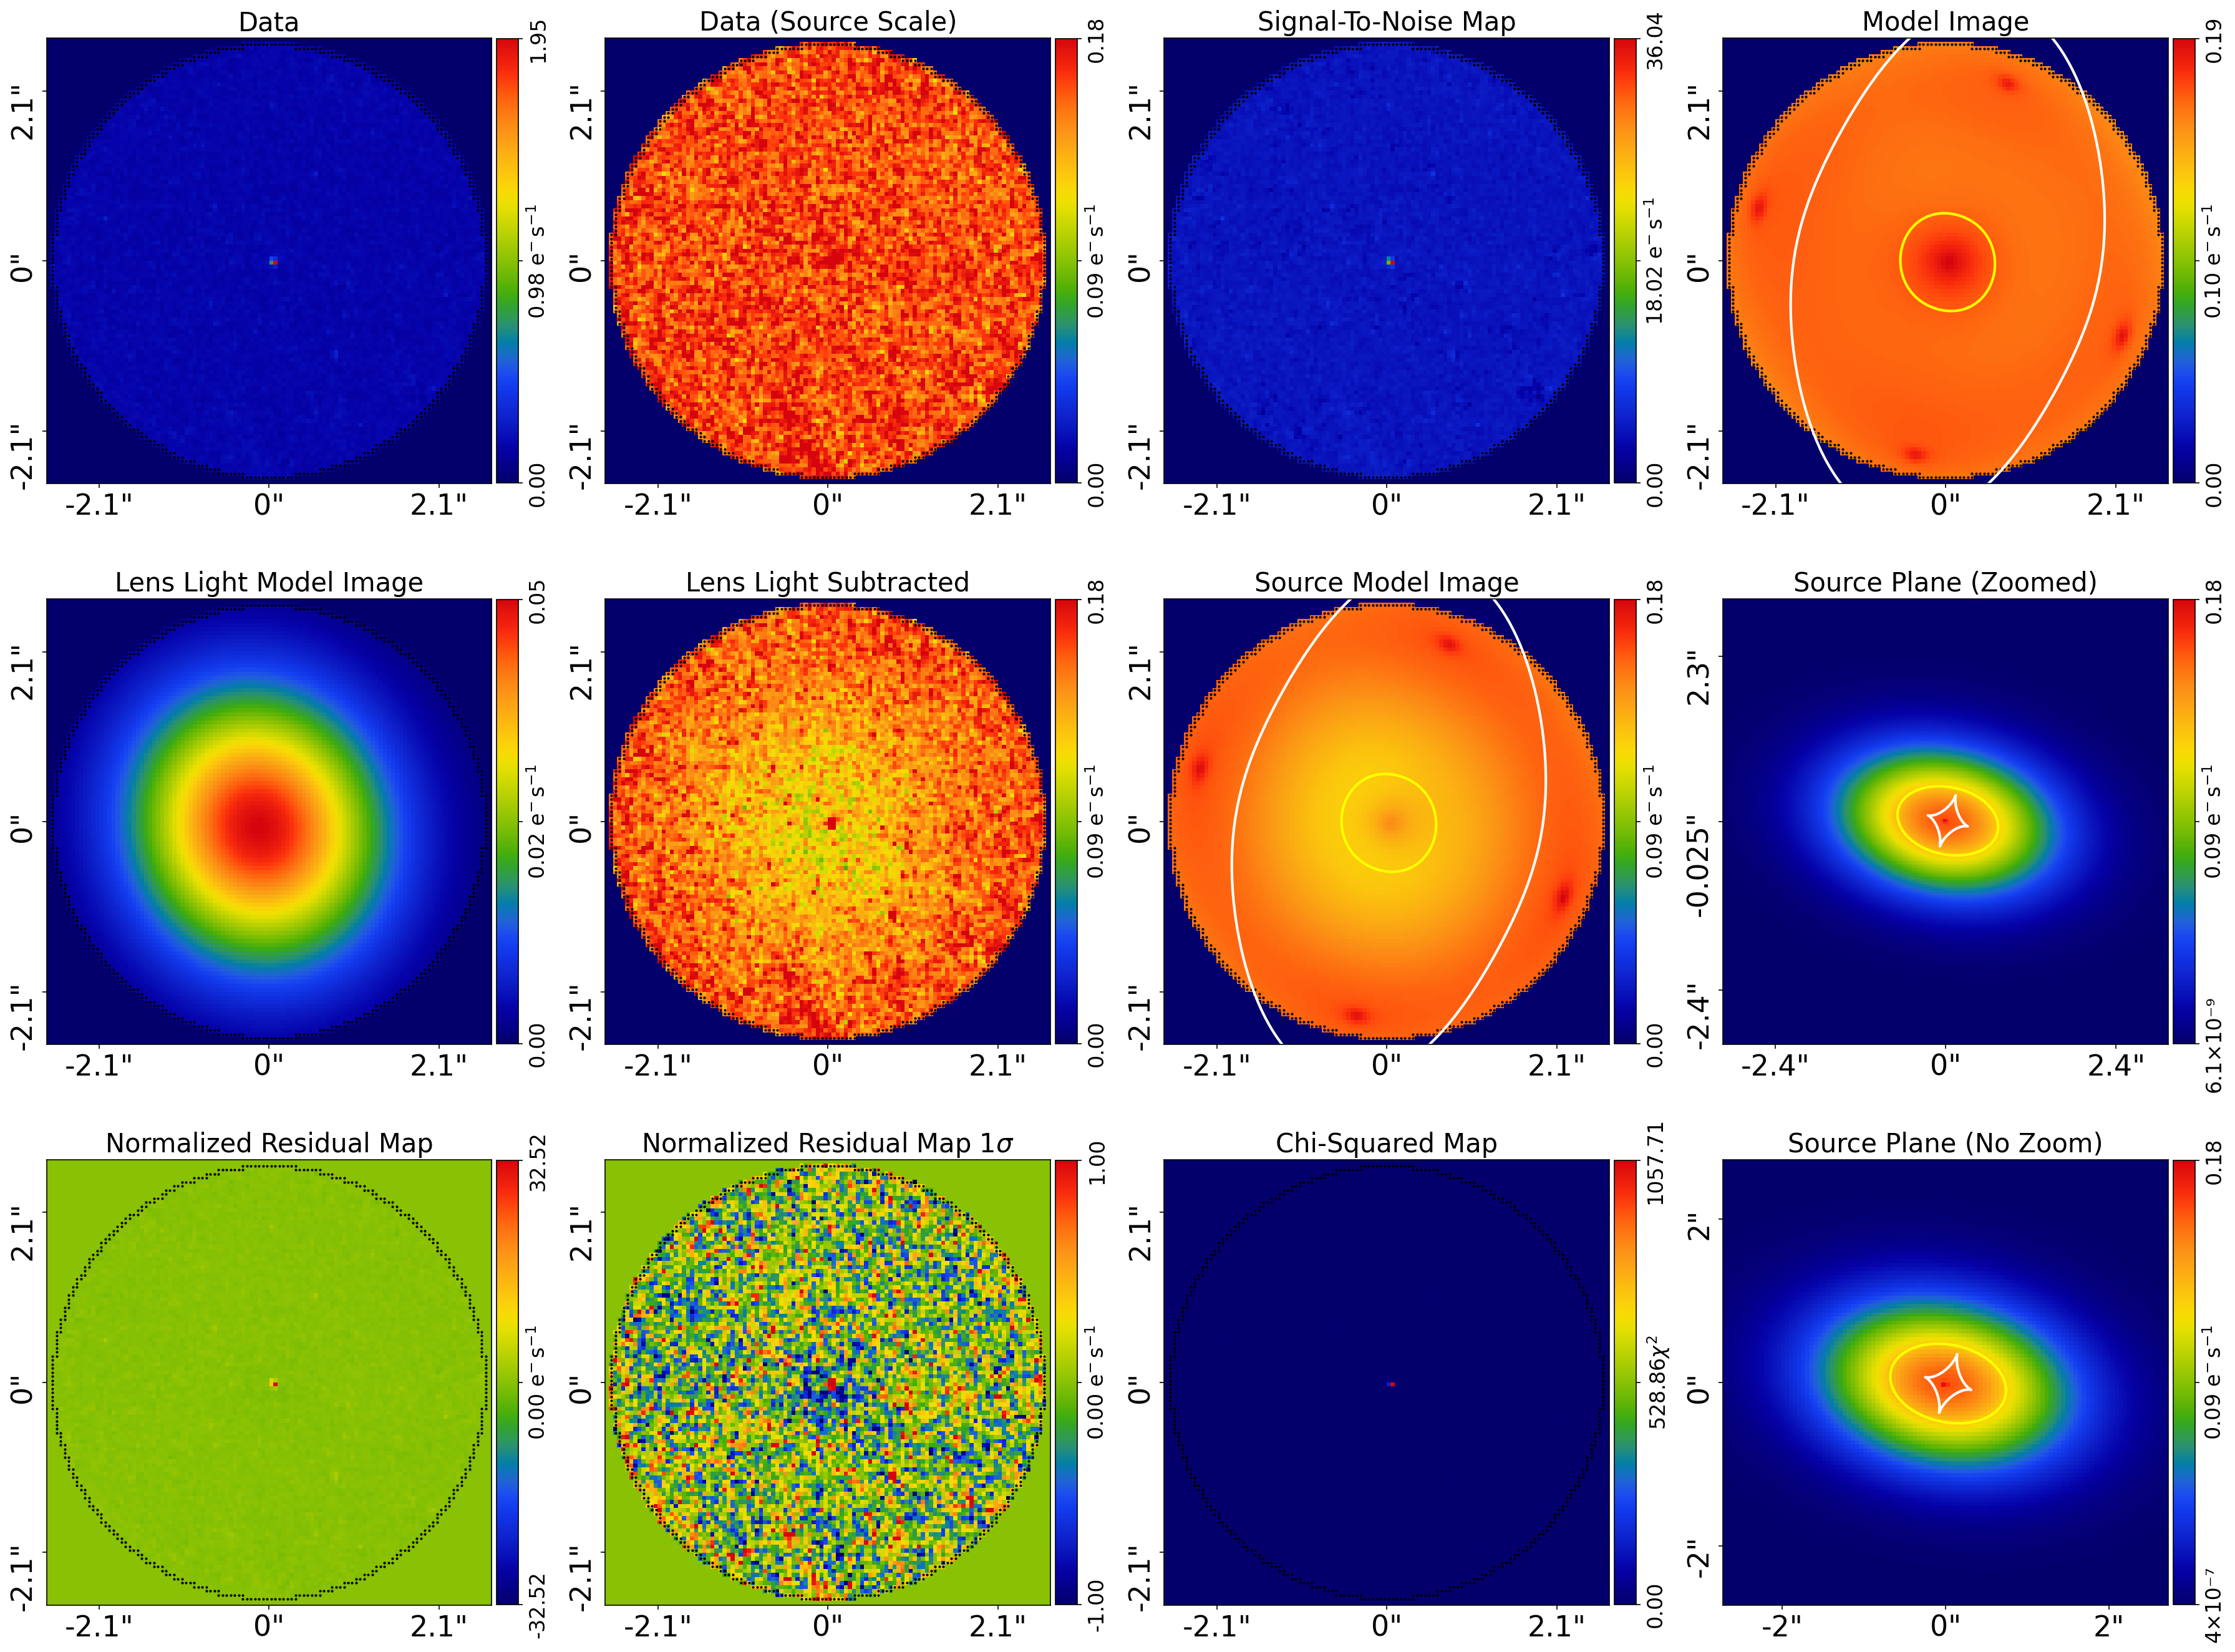

In [5]:
_HAVE = (RESULTS_ROOT / "agel013322_direct" / "summary.json").exists()
_FORCE = os.environ.get("LTA_RUN_HEAVY", "").lower() in ("1", "true", "yes")

if _HAVE and not _FORCE:
    print("[fit] Loading committed Cannon result.")
    show_result("agel013322_direct")
    result = None
elif not _HAVE and not _FORCE:
    print("[fit] No committed results yet.")
    print("[fit] Submit via fit_example_agel_real_target.py --part direct")
    print("[fit] (Wall: ~1-2 h on 32 cores. Local LTA_RUN_HEAVY=1 will be slow.)")
    result = None
else:
    print("[fit] Heavy fit on real data — local run is slow; Cannon recommended.")
    result = None

## 3. Audit — physical bar on real data

The Module 11 physical bar applies to real data the same way as to mocks, with two important differences:

1. **No truth values to compare against.** You can only audit residual *structure* and physical *plausibility* — not posterior accuracy.
2. **Coherent residuals can come from many sources** that don't exist in mocks: PSF mismatch, drizzle correlations, lens-light wing leakage, undocumented neighbouring galaxies, cosmic-ray cores in single-exposure data. The skill of real-data analysis is *attribution* — diagnosing *which* of these is producing the residuals you see.

### Verdict template

```
Verdict: PASS | SUSPECT | FAIL

Numeric summary
  log_Z:       _____
  χ²/N:        _____
  max |res|:   _____σ
  n_params:    _____

Panel walk (physical bar)
  1. Residual map:        _____  (coherent? where?)
  2. Residual map 1σ:     _____
  3. Chi² map:            _____  (hot spots on arc / lens / mask edge?)
  4. Source Plane Zoomed: _____  (caustic shape physical?)
  5. Lens Light Subtracted: _____
  6. model_results.txt:   _____  (any prior rail-pinned?)

Real-data diagnosis (which of these is producing the residuals?)
  - PSF mismatch:           _____
  - Drizzle correlations:   _____ (check: σ_inflate × residual)
  - Lens-light wing leak:   _____ (Sersic is too rigid; try MGE)
  - Neighbouring galaxy:    _____ (segment catalog has nearby IDs?)
  - Mask edge effects:      _____
```

*Worked verdict pending Cannon results.*

## 4. Comparison to AGEL DR2 catalog (planned)

Once the Cannon fit lands, compare:

| Quantity | This fit | AGEL DR2 catalog | Δ |
|---|---|---|---|
| θ_E | _____ | _____ | _____ |
| γ′ | _____ | (not catalogued?) | — |
| ell | _____ | _____ | _____ |

If a published lensing model exists for AGEL013322, also compare γ′, ε, source size.

## 5. Exercises

See README §Exercises for the full list. Most-impactful three:

1. **MGE lens light** (mirror `mge_to_physical/`) — for the same reasons we MGE'd lenstronomy_mock_1's cuspy lens light, MGE'ing AGEL013322's faint lens light should sharpen the source fit.
2. **Empirical PSF** — stack 5 stars from the segment catalog and replace the Gaussian placeholder. The fit residuals near the lens centre should drop noticeably.
3. **Redshift marginalisation** — the spec-z values have ~few-percent (lens) and ~10% (source) uncertainty. Treat them as nuisance parameters with Gaussian priors instead of fixed values. Quantify the θ_E shift.

## References

- See `README.md` §References.

---

*Learning to Autolens — Examples / agel_real_target / 01*  
*Rodrigo Córdova Rosado, Harvard CfA*